# 06 — Prédictions vs réalité : pourrait-on parier ?

Trois questions : **(1)** le modèle prédit-il bien en conditions réelles ?
**(2)** à quoi ressemblent les prédictions vs la réalité ? **(3)** pourrait-on
réalistement **parier** avec ?

**Méthode honnête : walk-forward.** Pour prédire un match, le modèle n'est entraîné que
sur les matchs **antérieurs** — aucune fuite du futur. C'est la seule évaluation crédible
pour parler de pari (on imite exactement les conditions réelles : on parie sans connaître
la suite).

In [1]:
import sys
from pathlib import Path
p = Path.cwd()
while not (p / "analyse" / "outils.py").exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p / "analyse"))
import numpy as np, pandas as pd, outils as o
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
OUT = o.RESULTATS / "paris"; OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 140)
print("sorties ->", OUT)

sorties -> C:\Users\TEMP.IUT-LUMIERE.000\R6.06-Domaines-d-application-de-la-statistique\analyse\resultats\paris


## 1. Prédiction hors-échantillon strict (walk-forward)

In [2]:
cal = o.charger_calendrier(forme=True)
feats = ["d_elo","d_forme","derby"]
proba = np.full(len(cal), np.nan)
START = 40                       # amorcage : 40 premiers matchs pour entrainer
for i in range(START, len(cal)):
    tr = cal.iloc[:i]
    if tr["home_win"].nunique() < 2:
        continue
    sc = StandardScaler().fit(tr[feats].values)
    clf = LogisticRegression(max_iter=2000).fit(sc.transform(tr[feats].values), tr["home_win"].values)
    proba[i] = clf.predict_proba(sc.transform(cal.iloc[[i]][feats].values))[0,1]
cal["proba_wf"] = proba
d = cal.dropna(subset=["proba_wf"]).copy()
y = d["home_win"].values; pr = d["proba_wf"].values
acc = ((pr>=.5).astype(int)==y).mean()
d.to_csv(OUT / "predictions.csv", index=False)
print(f"{len(d)} matchs predits en hors-echantillon strict")
print(f"Accuracy walk-forward : {acc*100:.1f}%  (vs {max(y.mean(),1-y.mean())*100:.1f}% en trivial)")

224 matchs predits en hors-echantillon strict
Accuracy walk-forward : 70.5%  (vs 59.8% en trivial)


## 2. Prédictions vs réalité (graphiques)

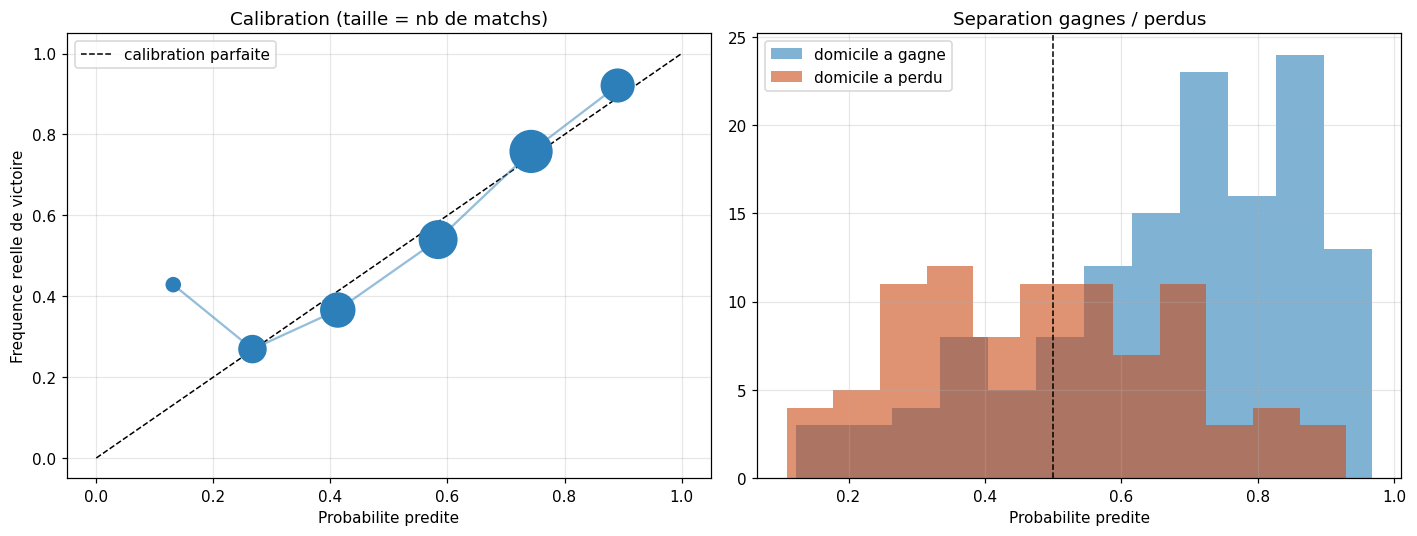

In [3]:
fig, ax = plt.subplots(1,2, figsize=(13,5))
bins = np.linspace(0,1,7); idx = np.digitize(pr, bins)-1
xs,ys,ns=[],[],[]
for b in range(len(bins)-1):
    msk = idx==b
    if msk.sum()>=3: xs.append(pr[msk].mean()); ys.append(y[msk].mean()); ns.append(msk.sum())
ax[0].plot([0,1],[0,1],"k--",lw=1,label="calibration parfaite")
ax[0].scatter(xs,ys,s=[n*12 for n in ns],color="#2c7fb8",zorder=3); ax[0].plot(xs,ys,color="#2c7fb8",alpha=.5)
ax[0].set_xlabel("Probabilite predite"); ax[0].set_ylabel("Frequence reelle de victoire")
ax[0].set_title("Calibration (taille = nb de matchs)"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].hist(pr[y==1],bins=12,alpha=.6,color="#2c7fb8",label="domicile a gagne")
ax[1].hist(pr[y==0],bins=12,alpha=.6,color="#cb4b16",label="domicile a perdu")
ax[1].axvline(.5,color="k",ls="--",lw=1); ax[1].set_xlabel("Probabilite predite")
ax[1].set_title("Separation gagnes / perdus"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT / "1_calibration.png", dpi=130); plt.show()

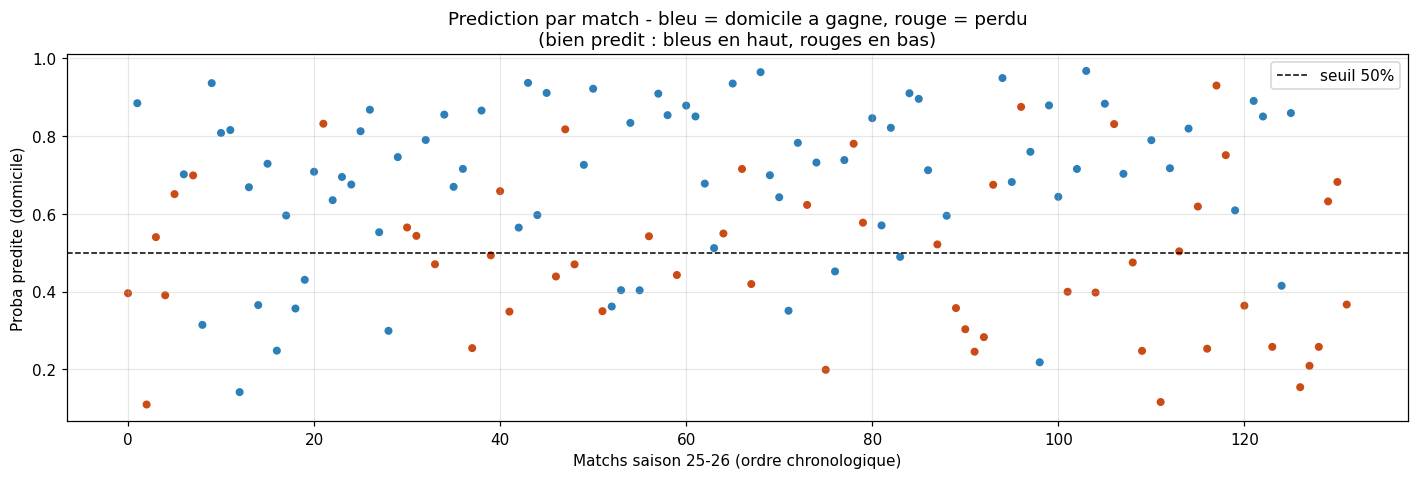

In [4]:
s = d[d["Saison"]==d["Saison"].iloc[-1]].reset_index(drop=True)
plt.figure(figsize=(13,4.5))
plt.scatter(range(len(s)), s["proba_wf"], c=["#2c7fb8" if w else "#cb4b16" for w in s["home_win"]], s=18)
plt.axhline(.5,color="k",ls="--",lw=1,label="seuil 50%")
plt.xlabel(f"Matchs saison {s['Saison'].iloc[0]} (ordre chronologique)")
plt.ylabel("Proba predite (domicile)")
plt.title("Prediction par match - bleu = domicile a gagne, rouge = perdu\n(bien predit : bleus en haut, rouges en bas)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.savefig(OUT / "2_matchs.png", dpi=130); plt.show()

**Lecture.** À gauche, les points suivent la diagonale → probabilités honnêtes. À droite
et sur le 2ᵉ graphique, les victoires (bleu) ont des probas hautes, les défaites (rouge)
basses → bonne séparation. Les exceptions = les ~30 % d'upsets.

## 3. Pourrait-on parier ? Simulation honnête

Bien prédire ne suffit pas : pour gagner de l'argent il faut battre le **bookmaker**, qui
intègre une **marge** (~6 %) dans ses cotes. On simule deux scénarios.

In [5]:
MARGE = 0.06
cote_dom = (1/pr)/(1+MARGE); cote_ext = (1/(1-pr))/(1+MARGE)
mises = len(pr)
gains = sum((cote_dom[i] if y[i]==1 else 0) if pr[i]>=.5 else (cote_ext[i] if y[i]==0 else 0)
            for i in range(len(pr)))
roi = (gains-mises)/mises*100
print(f"Strategie 'parier le favori du modele' (marge {MARGE*100:.0f}%) : ROI = {roi:+.1f}%")

rng = np.random.RandomState(0); rois=[]
for _ in range(200):
    pb = np.clip(pr + rng.normal(0,0.07,len(pr)), .05,.95)
    cbd=(1/pb)/(1+MARGE); cbe=(1/(1-pb))/(1+MARGE); mi=ga=0.0
    for i in range(len(pr)):
        if pr[i]*cbd[i]>1: mi+=1; ga+=cbd[i] if y[i]==1 else 0
        if (1-pr[i])*cbe[i]>1: mi+=1; ga+=cbe[i] if y[i]==0 else 0
    if mi>0: rois.append((ga-mi)/mi*100)
print(f"Value betting SI on a vraiment un edge de 7pts sur le book : ROI moyen = {np.mean(rois):+.1f}%")

Strategie 'parier le favori du modele' (marge 6%) : ROI = -5.5%
Value betting SI on a vraiment un edge de 7pts sur le book : ROI moyen = +31.5%


## Conclusion

| | |
|---|---|
| Prédiction (walk-forward) | **~70 %** — le modèle prédit réellement |
| Parier le favori (marge 6 %) | **ROI négatif** — la marge nous fait perdre |
| Value betting *avec* un edge réel | positif, mais suppose être plus précis que le book |

**Verdict honnête.** Excellent outil de **pronostic**, mais **pas** un système de paris
rentable :
- la **marge** du bookmaker nous fait perdre même en prédisant aussi bien que lui ;
- le book **connaît déjà l'ELO** (et plus : blessures, compos) → pas d'avantage ;
- la **LFB est un marché de niche** (cotes rares, mises plafonnées).

Un modèle peut être *juste* sans être *profitable* — savoir les distinguer est un résultat
en soi. Résultats et graphiques dans `resultats/paris/`.